# 11 — Feature selection: clusters + clustered permutation importance (WP2)

Stage 2 of the 3-stage feature-selection pipeline, on the **56 MODEL features** (stage-1
univariate ranking lives in `outputs/tables/feature_ranking_univariate.csv`). `vrp` /
`jpy_strength` also exist as routing triggers (handoff §5.4) — routing is **out of scope**
here: dropping model copies never touches the routing engine.

Method: hierarchical clustering on the development matrix (distance 1−|ρ|, average linkage,
cut t=0.4), then cluster importance = mean drop over 20 seeded repeats of the soft-median
ensemble **val AUC-PR** when all columns of the cluster are jointly row-shuffled in the val
matrix. Permutation = re-scoring only (models fit once per fold and kept; reference percentile
distributions untouched). Cross-fold aggregation is n_pos-weighted. No holdout contact.

In [1]:
import os, sys, time
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')  # handoff par.5.3: deterministic AE
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.feature_selection import (correlation_cluster_count, correlation_clusters,
                                   clustered_permutation_importance,
                                   plot_cluster_importance)
pd.set_option('display.width', 160)

## Correlation clusters (development matrix, 1−|ρ|, average linkage)

In [2]:
print('cluster counts by cut:', correlation_cluster_count())  # t=0.4 expected ~36
clusters = correlation_clusters(threshold=0.4)   # -> outputs/tables/feature_clusters.csv
sizes = clusters.groupby('cluster_id').size()
print(f'{clusters.cluster_id.nunique()} clusters at t=0.4 '
      f'({(sizes == 1).sum()} singletons, largest = {sizes.max()})')
multi = (clusters.groupby('cluster_id')['feature'].apply('|'.join)
         .loc[sizes[sizes > 1].index].rename('members').to_frame())
multi

cluster counts by cut: {0.3: 44, 0.4: 36, 0.5: 26}
36 clusters at t=0.4 (22 singletons, largest = 4)


,members
cluster_id,
1,em_spread|hy_ig_spread|us_de_10y
4,de_term_10y_2y|us_term_10y_2y
7,GTITL10YR|GTITL2YR|GTITL30YR
11,DXY|GBP
15,equity_bond_rot|hy_ig_spread_chg4w
18,CRY|Cl1
19,EMUSTRUU|LF98TRUU|LG30TRUU|LP01TREU
20,MXBR|MXRU
21,MXCN|MXIN


## Clustered permutation importance
Per fold: fit the 4 detectors once (leakage-free, fresh per-fold scalers), keep them;
20 joint row-shuffles per cluster; drop in soft-median ensemble val AUC-PR; n_pos-weighted
aggregation across the 5 folds. ~3 min (5 AE fits + batched re-scoring).

In [3]:
t0 = time.time()
imp = clustered_permutation_importance(clusters)  # -> outputs/tables/cluster_importance.csv
print(f'{time.time()-t0:.0f}s')
imp.head(12)[['cluster_id', 'members', 'n_members', 'mean_drop', 'std_drop']]

fold 1: baseline AUC-PR=0.674, 36 clusters x 20 repeats done


fold 2: baseline AUC-PR=0.639, 36 clusters x 20 repeats done


fold 3: baseline AUC-PR=0.030, 36 clusters x 20 repeats done


fold 4: baseline AUC-PR=0.177, 36 clusters x 20 repeats done


fold 5: baseline AUC-PR=0.364, 36 clusters x 20 repeats done
206s


,cluster_id,members,n_members,mean_drop,std_drop
0,3,it_de_10y,1,0.097616,0.023400
1,8,it_de_10y_chg4w,1,0.032897,0.023329
2,19,EMUSTRUU|LF98TRUU|LG30TRUU|LP01TREU,4,0.023869,0.010142
3,15,equity_bond_rot|hy_ig_spread_chg4w,2,0.011446,0.005973
4,26,GT10|LUACTRUU|LUMSTRUU|USGG2YR,4,0.007617,0.006807
5,20,MXBR|MXRU,2,0.007305,0.006315
6,21,MXCN|MXIN,2,0.006409,0.005268
7,2,gold_oil_ratio,1,0.006113,0.005719
8,22,MXEU|MXUS,2,0.005378,0.004310
9,24,GTDEM10Y|GTGBP30Y,2,0.005369,0.006971


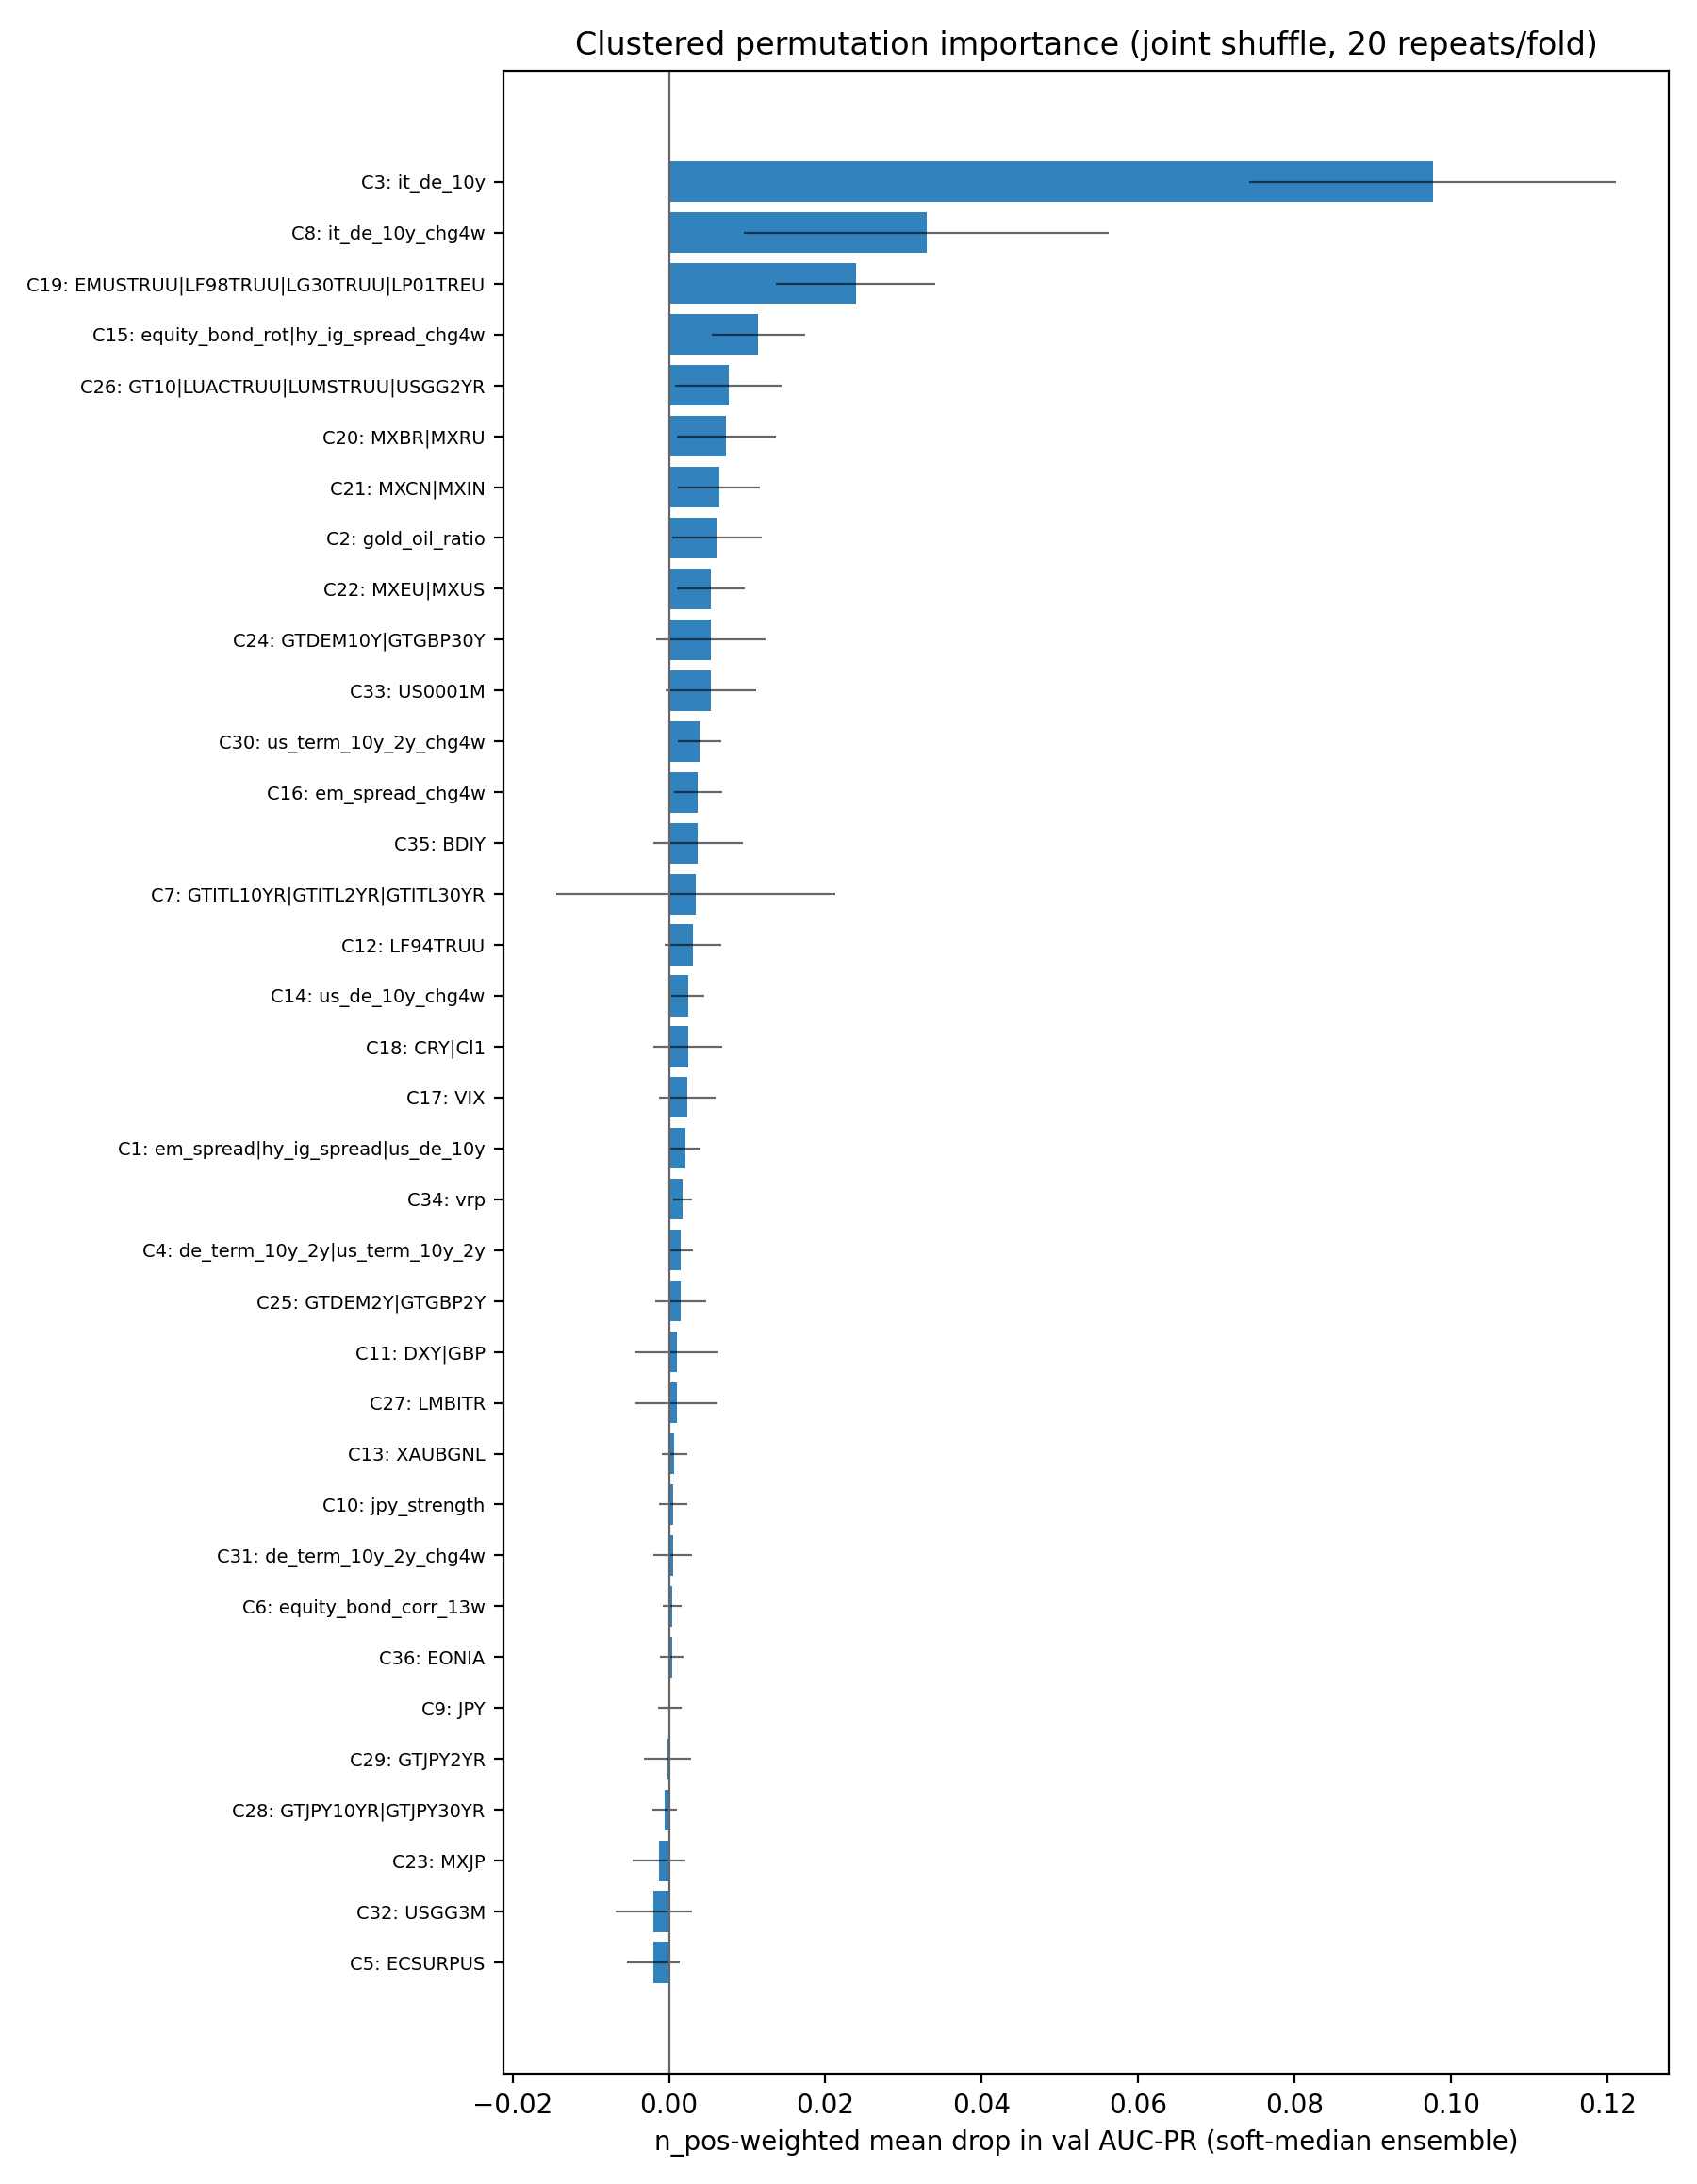

In [4]:
fig_path = plot_cluster_importance(imp)   # -> outputs/figures/cluster_importance.png
from IPython.display import Image
Image(filename=str(fig_path), width=900)

## Sanity check (pre-registered expectation)
Clusters containing **VIX**, **it_de_10y** and the **credit block** are expected near the top.

In [5]:
ranked = imp.reset_index(drop=True).assign(rank=lambda d: d.index + 1)
def where(token):
    hit = ranked[ranked['members'].str.contains(token)].iloc[0]
    return int(hit['rank']), hit['members'], hit['mean_drop']
for token in ['it_de_10y', 'LF98TRUU', 'hy_ig_spread', 'VIX']:
    r, m, d = where(token)
    tag = 'PASS' if r <= 10 else 'ATTENTION'
    print(f'[{tag}] {token:<14} -> rank {r:>2}/36  drop={d:+.4f}  cluster: {m}')

[PASS] it_de_10y      -> rank  1/36  drop=+0.0976  cluster: it_de_10y
[PASS] LF98TRUU       -> rank  3/36  drop=+0.0239  cluster: EMUSTRUU|LF98TRUU|LG30TRUU|LP01TREU
[PASS] hy_ig_spread   -> rank  4/36  drop=+0.0114  cluster: equity_bond_rot|hy_ig_spread_chg4w
[ATTENTION] VIX            -> rank 19/36  drop=+0.0024  cluster: VIX


### Discussion — the VIX cluster is NOT near the top, and that is informative
`it_de_10y` (rank 1, drop ≈ 0.09) and the credit block `EMUSTRUU|LF98TRUU|LG30TRUU|LP01TREU`
(rank 3) behave as expected, as does the rotation/credit-momentum cluster
`equity_bond_rot|hy_ig_spread_chg4w` (rank 4). **VIX does not** (rank ~22, drop ≈ 0): at t=0.4 it
is a *singleton* cluster, but its strongest development-set correlates — `hy_ig_spread` (|ρ|≈0.56),
`us_de_10y` (≈0.54), `equity_bond_rot` (≈0.46) — sit just **below** the |ρ|>0.6 merge threshold and
live in clusters that stay intact when VIX is shuffled. The four detectors are unsupervised: with 55
intact columns carrying nearly the same stress signal, permuting VIX alone barely moves the
anomaly geometry, so its *marginal* importance collapses even though its stage-1 *univariate* AP is
the best of all 56 (0.749). This is the classic correlated-features caveat of permutation importance
— and exactly why stage 3 picks cluster *representatives* (VIX still enters subsets through its own
cluster representative: itself) rather than thresholding on this ranking alone.